# ANOVA

In [1]:
# Numerical arrays.
import numpy as np

# Plotting.
import matplotlib.pyplot as plt

# Statistical functions.
import scipy.stats as stats

# Mathematical functions.
import math

# Data frames.
import pandas as pd

# Combinations and permutations.
import itertools as it

## More Samples

In [2]:
# First sample.
sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)

# Second sample.
sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)

# Third sample.
sample_c = np.random.normal(loc=10.0, scale=1.0, size=50)

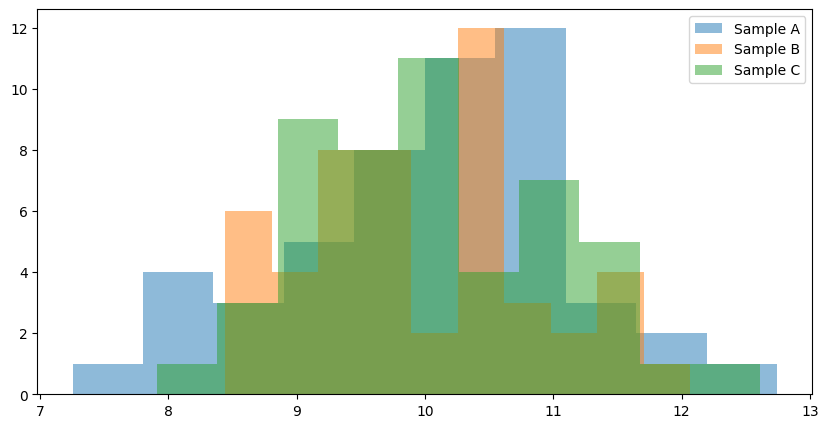

In [3]:
# Create histograms.
fig, ax = plt.subplots(figsize=(10, 5))

# Histogram of the first sample.
ax.hist(sample_a, bins=10, alpha=0.5, label='Sample A')

# Histogram of the second sample.
ax.hist(sample_b, bins=10, alpha=0.5, label='Sample B')

# Histogram of the third sample.
ax.hist(sample_c, bins=10, alpha=0.5, label='Sample C')

# Add a legend.
ax.legend();

In [4]:
# Independent samples t-test on sample_a and sample_b.
t_statistic, p_value = stats.ttest_ind(sample_a, sample_b)

# Show.
t_statistic, p_value

(np.float64(0.43525547235937734), np.float64(0.6643340863128386))

In [5]:
# Independent samples t-test on sample_b and sample_a.
t_statistic, p_value = stats.ttest_ind(sample_b, sample_a)

# Show.
t_statistic, p_value

(np.float64(-0.43525547235937734), np.float64(0.6643340863128386))

In [6]:
# Independent samples t-test on sample_a and sample_c.
t_statistic, p_value = stats.ttest_ind(sample_a, sample_c)

# Show.
t_statistic, p_value

(np.float64(0.022412009711843803), np.float64(0.982164870734749))

In [7]:
# Independent samples t-test on sample_b and sample_c.
t_statistic, p_value = stats.ttest_ind(sample_b, sample_c)

# Show.
t_statistic, p_value

(np.float64(-0.44954209517488797), np.float64(0.654033342150155))

## $n$ Samples

In [8]:
# Number of samples.
n = 4

In [9]:
# Show the sample labels.
print(list(range(4)))

[0, 1, 2, 3]


For 4 samples, we can perform 6 t-tests:

[0, 1]  
[0, 2]  
[0, 3]  
[1, 2]  
[1, 3]  
[2, 3]  

In [10]:
# Number of ways of selecting two samples from n.
math.comb(n, 2)

6

In [11]:
# Suppose we had 6 samples.
n = 6
math.comb(n, 2)

15

In [12]:
# Suppose we had 7 samples.
n = 7
math.comb(n, 2)

21

## Type I Errors

In [13]:
def simulate_ttest(alpha=0.05):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)
    
    # Perform the t-test.
    _, p_value = stats.ttest_ind(sample_a, sample_b)
    
    # Decide whether to reject the null hypothesis.
    if p_value < alpha:
        return True
    else:
        return False

In [14]:
# Number of rejections.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_ttest():
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

497

In [15]:
def simulate_three_ttest(alpha=0.05):
    # Geneate a random sample a.
    sample_a = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample b.
    sample_b = np.random.normal(loc=10.0, scale=1.0, size=50)
    # Generate similar sample c.
    sample_c = np.random.normal(loc=10.0, scale=1.0, size=50)
    
    # Perform the t-test one.
    _, p_value0 = stats.ttest_ind(sample_a, sample_b)
    _, p_value1 = stats.ttest_ind(sample_a, sample_c)
    _, p_value2 = stats.ttest_ind(sample_b, sample_c)
    
    # Return the number of null hypothesis rejections.
    no_rejections = 0
    if p_value0 < alpha:
      no_rejections += 1
    if p_value1 < alpha:
      no_rejections += 1
    if p_value2 < alpha:
      no_rejections += 1
    
    return no_rejections

In [16]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_three_ttest() > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

1272

In [17]:
# Generate all pairs of integers from 0 to 6.
for i, j in it.combinations(range(7), 2):
  print(f'{i},{j}')

0,1
0,2
0,3
0,4
0,5
0,6
1,2
1,3
1,4
1,5
1,6
2,3
2,4
2,5
2,6
3,4
3,5
3,6
4,5
4,6
5,6


In [18]:
def simulate_multiple_ttest(no_samples=7, alpha=0.05):
    # Geneate no_samples random samples.
    samples = np.random.normal(size=(no_samples, 50))
    
    # Keep track of nubmer of null hypothesis rejections.
    no_rejections = 0

    # Performs all t-tests.
    for i, j in it.combinations(range(no_samples), 2):
      _, p_value = stats.ttest_ind(samples[i], samples[j])
      if p_value < alpha:
        no_rejections += 1
    
    return no_rejections

In [19]:
# Set no_rejections to zero.
no_rejections = 0

# Run several simulations.
for _ in range(10000):
    # Check if the null hypothesis is rejected.
    if simulate_multiple_ttest() > 0:
        # Increment the number of rejections.
        no_rejections += 1

# Show the number of rejections.
no_rejections

4352

## ANOVA

https://statistics.laerd.com/spss-tutorials/one-way-anova-using-spss-statistics.php  

In [20]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

In [21]:
# Create data frame.
df = pd.DataFrame({'Beginner': beginner, 'Intermediate': intermediate, 'Advanced': advanced})

# Show.
df

,Beginner,Intermediate,Advanced
0,26.695263,27.696804,24.810101
1,29.347162,22.390080,24.119320
2,26.658196,24.801336,25.870187
3,32.825486,18.710485,21.447859
4,21.906410,28.937180,21.590589
5,25.956682,20.458544,30.231614
6,25.196378,23.246088,29.560091
7,25.711531,29.728310,23.432454
8,28.209708,28.684049,18.852978
9,25.662086,23.500807,24.420080


In [22]:
# Describe.
df.describe()

,Beginner,Intermediate,Advanced
count,10.000000,10.000000,10.000000
mean,26.816890,24.815368,24.433527
std,2.877492,3.811097,3.517344
min,21.906410,18.710485,18.852978
25%,25.674447,22.604082,22.051055
50%,26.307439,24.151072,24.269700
75%,27.831097,28.437238,25.605166
max,32.825486,29.728310,30.231614


https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.f_oneway.html  

In [23]:
# Perform ANOVA.
f_statistic, p_value = stats.f_oneway(df['Beginner'], df['Intermediate'], df['Advanced'])

# Show.
f_statistic, p_value

(np.float64(1.3975829093141257), np.float64(0.26451020076677617))

https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.tukey_hsd.html

In [24]:
# Tukey's HSD.
res = stats.tukey_hsd(df['Beginner'], df['Intermediate'], df['Advanced'])

# Show.
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      2.002     0.404    -1.795     5.798
 (0 - 2)      2.383     0.282    -1.414     6.180
 (1 - 0)     -2.002     0.404    -5.798     1.795
 (1 - 2)      0.382     0.966    -3.415     4.179
 (2 - 0)     -2.383     0.282    -6.180     1.414
 (2 - 1)     -0.382     0.966    -4.179     3.415



## Presenting the Data

In [25]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

# Concatenate arrays.
data = np.concatenate([beginner, intermediate, advanced])

# Show.
data

array([29.70917453, 25.05197546, 25.31537354, 23.67352105, 22.79506324,
       22.77132297, 25.1791179 , 24.50692883, 30.85540161, 30.57910524,
       28.67588875, 18.65810165, 20.7676665 , 22.39715115, 25.65398998,
       20.26264289, 26.56547849, 24.4830456 , 17.55901528, 22.57313639,
       23.85109649, 24.38994043, 27.97087293, 20.33002423, 24.20349026,
       28.79604216, 21.98178886, 24.29142573, 24.15941501, 25.8107537 ])

In [26]:
# Create the labels.
labels = ['Beginner'] * 10 + ['Intermediate'] * 10 + ['Advanced'] * 10

# Show.
labels

['Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Beginner',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Intermediate',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced',
 'Advanced']

In [27]:
# Create data frame.
df = pd.DataFrame({'Course': labels, 'Time': data})

# Show.
df

,Course,Time
0,Beginner,29.709175
1,Beginner,25.051975
2,Beginner,25.315374
3,Beginner,23.673521
4,Beginner,22.795063
5,Beginner,22.771323
6,Beginner,25.179118
7,Beginner,24.506929
8,Beginner,30.855402
9,Beginner,30.579105


In [28]:
# Pull the groups out.
b_times = df[df['Course'] == 'Beginner']['Time']
i_times = df[df['Course'] == 'Intermediate']['Time']
a_times = df[df['Course'] == 'Advanced']['Time']

# Perform ANOVA.
f, p = stats.f_oneway(b_times, i_times, a_times)

# Show.
f, p

(np.float64(2.8075602112316718), np.float64(0.07802872311910475))

In [29]:
# Tukey's HSD.
res = stats.tukey_hsd(b_times, i_times, a_times)

# Show.
print(res)

Pairwise Group Comparisons (95.0% Confidence Interval)
Comparison  Statistic  p-value  Lower CI  Upper CI
 (0 - 1)      3.284     0.064    -0.159     6.727
 (0 - 2)      1.465     0.549    -1.978     4.908
 (1 - 0)     -3.284     0.064    -6.727     0.159
 (1 - 2)     -1.819     0.402    -5.262     1.624
 (2 - 0)     -1.465     0.549    -4.908     1.978
 (2 - 1)      1.819     0.402    -1.624     5.262



## The F Statistic using numpy

https://en.wikipedia.org/wiki/F-test#One-way_analysis_of_variance

In [30]:
# From Laerd.
beginner = np.random.normal(27.2, 3.04777, 10)
intermediate = np.random.normal(23.6, 3.30656, 10)
advanced = np.random.normal(23.4, 3.23866, 10)

In [31]:
# Calculate the means.
beginner_mean = beginner.mean()
intermediate_mean = intermediate.mean()
advanced_mean = advanced.mean()

In [32]:
# Y(bar)_i from the formula.
Y_i = np.array([beginner_mean, intermediate_mean, advanced_mean])

# Show.
Y_i

array([29.44038877, 24.88385769, 22.95001285])

In [33]:
# Y(bar) from the formula.
Y = np.concatenate([beginner, intermediate, advanced]).mean()

# Show.
Y

np.float64(25.758086436841342)

In [34]:
# Before the sum of squares.
Y_i - Y

array([ 3.68230233, -0.87422875, -2.80807358])

In [35]:
# Calculate the sum of squares between.
(Y_i - Y)**2

array([13.55935047,  0.76427591,  7.88527724])

In [36]:
# Size of the samples.
n_i = np.array([beginner.size, intermediate.size, advanced.size])

# Show.
n_i

array([10, 10, 10])

In [37]:
# Number of groups.
K = 3

In [38]:
# From the formula.
n_i * (Y_i - Y)**2

array([135.59350474,   7.64275909,  78.85277244])

In [39]:
# From the formula.
(n_i * (Y_i - Y)**2).sum()

np.float64(222.089036265825)

In [40]:
# From the formula.
(n_i * (Y_i - Y)**2).sum() / (K - 1)

np.float64(111.0445181329125)

In [41]:
# Numerator.
numerator = (n_i * (Y_i - Y)**2).sum() / (K - 1)

In [42]:
# The total number of values.
N = n_i.sum()

# Show.
N

np.int64(30)

In [43]:
# From the formula.
less_means = np.concatenate([beginner - beginner_mean, intermediate - intermediate_mean, advanced - advanced_mean])

# Show.
less_means

array([ 1.47924272,  5.39194249, -6.93770732,  4.59770246, -2.80440438,
        0.75154364, -0.19188232, -0.17111878, -2.05819653, -0.057122  ,
        4.31679767, -3.12634794,  2.97183033,  5.47767796, -1.50821162,
        1.01626379,  1.42655688, -2.36835674, -4.0542749 , -4.15193543,
       -2.14541314, -2.5970843 ,  2.73053094,  2.79217387, -4.72714723,
       -1.58744471, -0.29974127,  3.22945758, -0.20132349,  2.80599175])

In [44]:
# From the formula.
np.sum(less_means**2)

np.float64(295.03874419224553)

In [45]:
# Denominator.
denominator = np.sum(less_means**2) / (N - K)

# Show.
denominator

np.float64(10.927360896009093)

In [46]:
# My F statistic calculation.
F = numerator / denominator

# Show.
F

np.float64(10.162061927822696)

In [47]:
# Calculate F using scipy.
stats.f_oneway(beginner, intermediate, advanced)

F_onewayResult(statistic=np.float64(10.162061927822704), pvalue=np.float64(0.0005126204822968473))

## End